# Grid-Aware MADRL Training Notebook（配电网潮流约束版）

SimBench `1-LV-rural1--0-sw` 拓扑，3 个 prosumer agent，每步运行一次
Newton-Raphson 潮流，奖励含电压 / 线路约束惩罚。

## 与 train_madrl.ipynb 的主要差异

| 项目 | train_madrl | **train_madrl_grid** |
|------|-------------|----------------------|
| 环境 | `energy_storage` | **`grid_pf`**（调用 pandapower）|
| 奖励 | `composite`（5 分量）| **`grid_composite`**（+r_v_pen / r_l_pen）|
| num_envs | 12（多进程）| **1**（pandapower 暂不支持多进程）|
| 评估 | `evaluate_runner` | **自定义循环**（episode_recorder + grid_recorder）|
| 可视化 | 奖励分解 + SoC 轨迹 | + **电压时序图 / 复合图 / 违规统计图** |

## ⚠ 性能说明

- `num_envs=1` + pandapower ≈50 ms/step → 训练速度约为普通版的 **1/12**
- `train_episodes=100` 约需 3–5 分钟
- simbench 网络首次加载需 3–5 秒（有模块级缓存，重启 kernel 后只慢一次）

In [1]:
from pathlib import Path
import sys

# 启用 IPython 自动重载，修改模块后无需重启内核
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

# 向上查找项目根目录（以 configs 文件夹为标志）
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root.")
# 将项目根目录加入 Python 搜索路径，确保后续 import 正常
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
project_root

WindowsPath('D:/GithubProject/MADRL_ESS')

In [2]:
import numpy as np

# 导入实验工具：构建训练运行器、获取检查点路径、汇总配置
from scripts.utils.experiment_notebook_utils import (
    build_runner,
    get_madrl_checkpoint_root,
    summarize_cfg,
)
# 导入 PyTorch 运行时配置和设备描述
from scripts.utils.torch_runtime import configure_torch_runtime, describe_device
# 导入实验配置组合函数和电网 profile
from configs import compose_experiment_config
from configs.profiles import apply_grid_profile
# 导入 MADRL 控制器
from controllers import MADRLController
# 导入 episode 记录工具（标准记录器）
from scripts.recorders.episode_recorder import append_step_record, init_episode_record
# 导入电网专用绘图函数：电池+电网复合图、约束违规汇总图、节点电压图
from scripts.plots.grid_plots import (
    plot_battery_and_grid,
    plot_grid_constraint_summary,
    plot_node_voltages,
)
# 导入电网记录器（记录电压、线路负载、违规信息）
from scripts.recorders.grid_recorder import append_grid_step_record, init_grid_record
# 导入训练轨迹绘图（电价-动作-SoC）
from scripts.plots.plots import plot_last_k_episodes_price_action_soc
# 导入奖励分解绘图
from scripts.plots.reward_plots import plot_reward_decomposition

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
# ── 训练规模 ──────────────────────────────────────────────────
algorithm          = "MADDPG"   # MADDPG | MATD3
train_episodes     = 10        # 快速验证用 50；正式训练用 300+
n_eval_episodes    = 3          # 评估 episode 数（用于电压可视化）
reward_plot_window = 20         # 奖励移动平均窗口
n_recent_to_plot   = 2          # 训练轨迹图展示的最近 episode 数

# ── 运行时 ────────────────────────────────────────────────────
seed           = 0
runtime_mode   = "performance"  # performance | strict_reproducibility
device_request = None           # None = 自动选 CUDA
require_cuda   = False

In [4]:
# 组合实验配置：使用 debug profile，指定算法、模型、奖励、观测等参数
cfg = compose_experiment_config(
    profile="debug",
    algorithm=algorithm,
    model_family="mlp",
    reward_type="composite",        # apply_grid_profile 会覆盖为 grid_composite
    observation_profile="simbench",
    forecast_type="perfect",
    vec_env_type="dummy",
    data_dir=project_root / "data",
    runtime_mode=runtime_mode,
    seed=seed,
    require_cuda=require_cuda,
)

# ── Grid 一键切换 ─────────────────────────────────────────────
# 设置：env_type="grid_pf", reward="grid_composite",
#       num_envs=1, vec_env_type="dummy",
#       sb_code="1-LV-rural1--0-sw", agent_bus_ids=[10,6,12]
apply_grid_profile(cfg, "rural1_phase1")

# 覆盖训练 episode 数
cfg.train.train_episodes = train_episodes

# 配置 PyTorch 运行时（设备选择、随机种子、确定性模式等）
runtime_state = configure_torch_runtime(
    cfg, device=device_request, seed=seed, require_cuda=require_cuda
)
# 获取设备描述信息（GPU 型号或 CPU）
device_info = describe_device(runtime_state)

# 汇总配置信息用于展示
summary = summarize_cfg(cfg)
summary["device_info"] = device_info
summary

{'algo': 'MADDPG',
 'batch_size': 128,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'dataset_type': 'csv_prosumer',
 'device': 'cuda:0',
 'env_type': 'grid_pf',
 'episode_limit': 192,
 'expected_completed_episodes_floor': 10,
 'forecast': 'perfect',
 'future_horizon': 24,
 'local_features': ['time', 'price', 'load', 'pv', 'soc'],
 'max_train_steps': None,
 'model_family': 'mlp',
 'num_envs': 1,
 'obs_builder_type': 'default',
 'parallel_rollout_iterations': 1920,
 'partial_steps_per_env_at_stop': 0,
 'resolved_train_steps': 1920,
 'reward': 'grid_composite',
 'runtime_mode': 'performance',
 'seed': 0,
 'sequence_features': ['price', 'load', 'pv'],
 'train_budget_source': 'train_episodes * episode_limit',
 'train_episodes': 10,
 'vec_env': 'dummy'}


{'algo': 'MADDPG',
 'env_type': 'grid_pf',
 'dataset_type': 'csv_prosumer',
 'obs_builder_type': 'default',
 'model_family': 'mlp',
 'reward': 'grid_composite',
 'forecast': 'perfect',
 'local_features': ['time', 'price', 'load', 'pv', 'soc'],
 'sequence_features': ['price', 'load', 'pv'],
 'vec_env': 'dummy',
 'num_envs': 1,
 'batch_size': 128,
 'train_episodes': 10,
 'episode_limit': 192,
 'future_horizon': 24,
 'max_train_steps': None,
 'resolved_train_steps': 1920,
 'parallel_rollout_iterations': 1920,
 'expected_completed_episodes_floor': 10,
 'partial_steps_per_env_at_stop': 0,
 'train_budget_source': 'train_episodes * episode_limit',
 'device': 'cuda:0',
 'runtime_mode': 'performance',
 'seed': 0,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'device_info': {'device': 'cuda:0',
  'cuda_available': True,
  'name': 'NVIDIA GeForce RTX 5080',
  'capability': '12.0',
  'total_memory_gb': 15.92}}

In [5]:
# 构建训练运行器（包含训练环境和评估环境）
runner = build_runner(cfg, seed=seed, env_name="GridTrain", number=1)
# 获取评估环境的奖励函数，用于后续绘图
plot_reward_fn = runner.env_evaluate.reward_fn

# 打印关键配置，确认电网环境已正确加载
print("env_type     =", cfg.env.env_type)
print("reward_type  =", cfg.reward.type)
print("num_envs     =", cfg.train.num_envs)
print("Obs schema   =", cfg.runtime.observation_schema)
print("Action dim   =", cfg.runtime.action_dim)
print("Reward metas =", [m.key for m in plot_reward_fn.component_meta])
# 期望: ['r_inc', 'r_pen', 'r_pbrs', 'r_soc', 'r_bonus', 'r_v_pen', 'r_l_pen']

d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\sim

env_type     = grid_pf
reward_type  = grid_composite
num_envs     = 1
Obs schema   = {'local': (3, 6), 'adjacency': (3, 3), 'price_seq': (25,), 'load_seq': (3, 25), 'pv_seq': (3, 25)}
Action dim   = 1
Reward metas = ['r_inc', 'r_pen', 'r_pbrs', 'r_soc', 'r_bonus', 'r_v_pen', 'r_l_pen']


In [6]:
# num_envs=1 + pandapower 每步约 50ms，比普通训练慢约 12 倍
# train_episodes=100, episode_limit=192 步，预计约 3~5 分钟
episodes_completed = runner.run()  # 启动训练循环
print(f"训练完成：{episodes_completed} episodes")
runner.perf_summary  # 打印性能统计摘要

Training:   0%|          | 0/1920 [00:00<?, ?iters/s]

训练完成：10 episodes


{'seed': 0,
 'runtime_mode': 'performance',
 'device': 'cuda:0',
 'total_wall_time_s': 66.99044760000015,
 'action_time_s': 2.3931109000131983,
 'env_step_time_s': 41.766350799989596,
 'update_time_s': 22.423158999996303,
 'update_calls': 1793,
 'steps_per_sec': 28.660802678380605,
 'avg_action_ms_per_iter': 1.2464119270902074,
 'avg_env_ms_per_iter': 21.753307708327913,
 'avg_update_ms_per_call': 12.505944785274012}

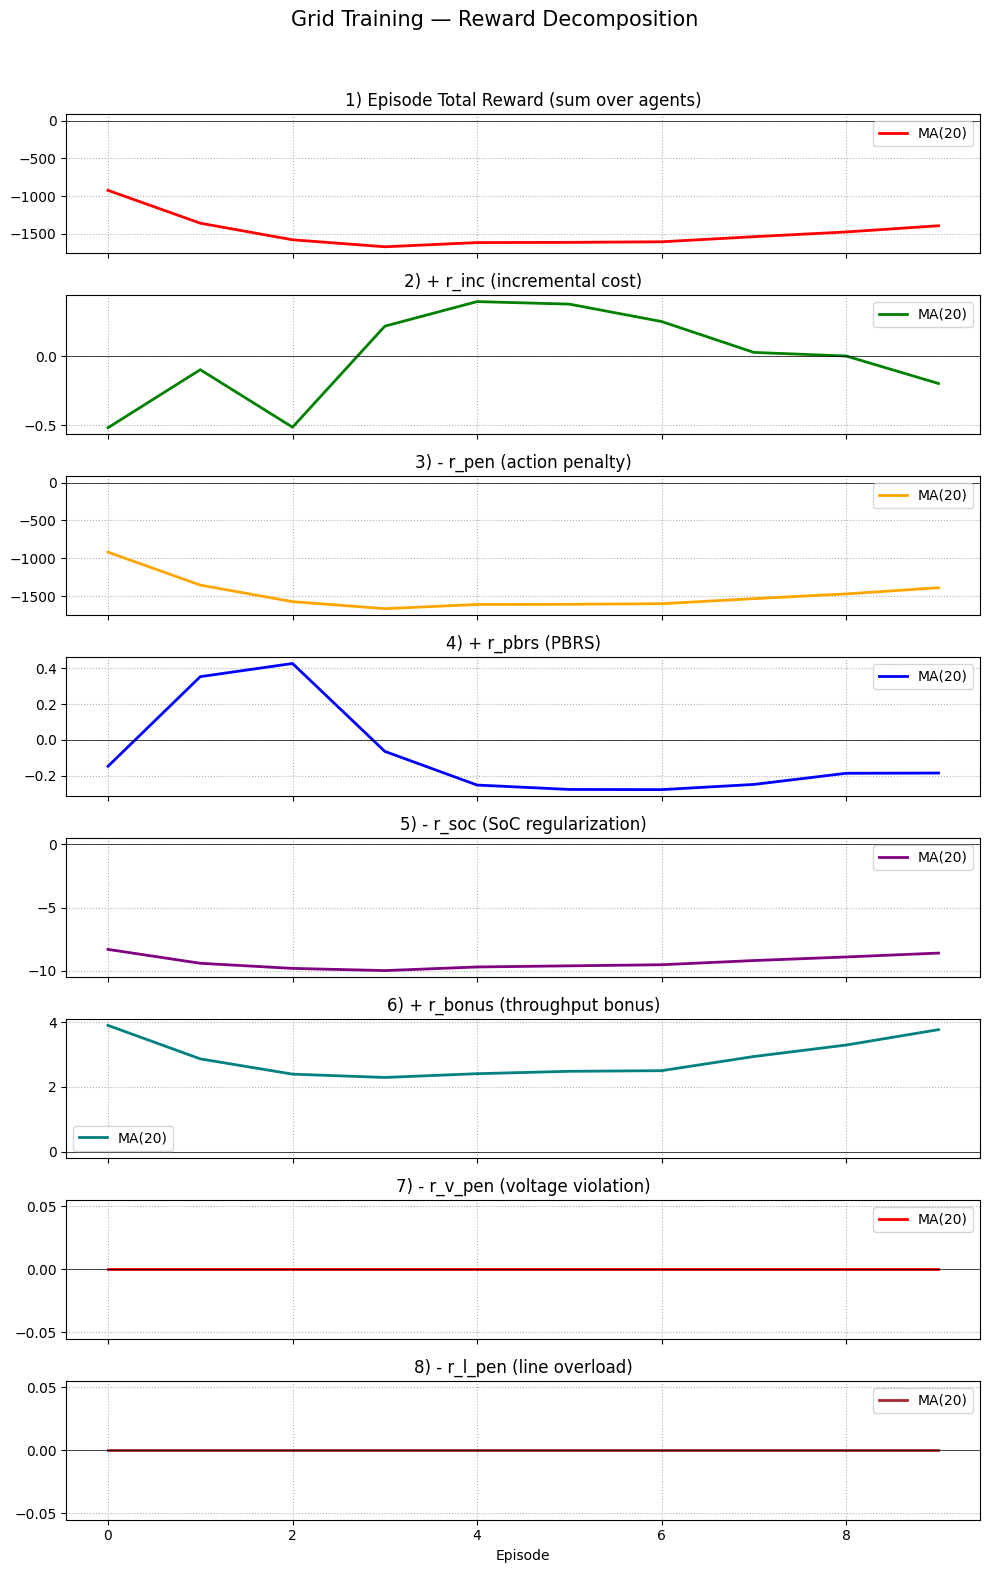

In [7]:
# 绘制奖励分解图，r_v_pen 和 r_l_pen 会自动出现在第 6、7 个子图
plot_reward_decomposition(
    history=runner.history,
    episode_rewards=runner.episode_rewards,
    reward_fn=plot_reward_fn,
    title="Grid Training — Reward Decomposition",
    window=reward_plot_window,
)

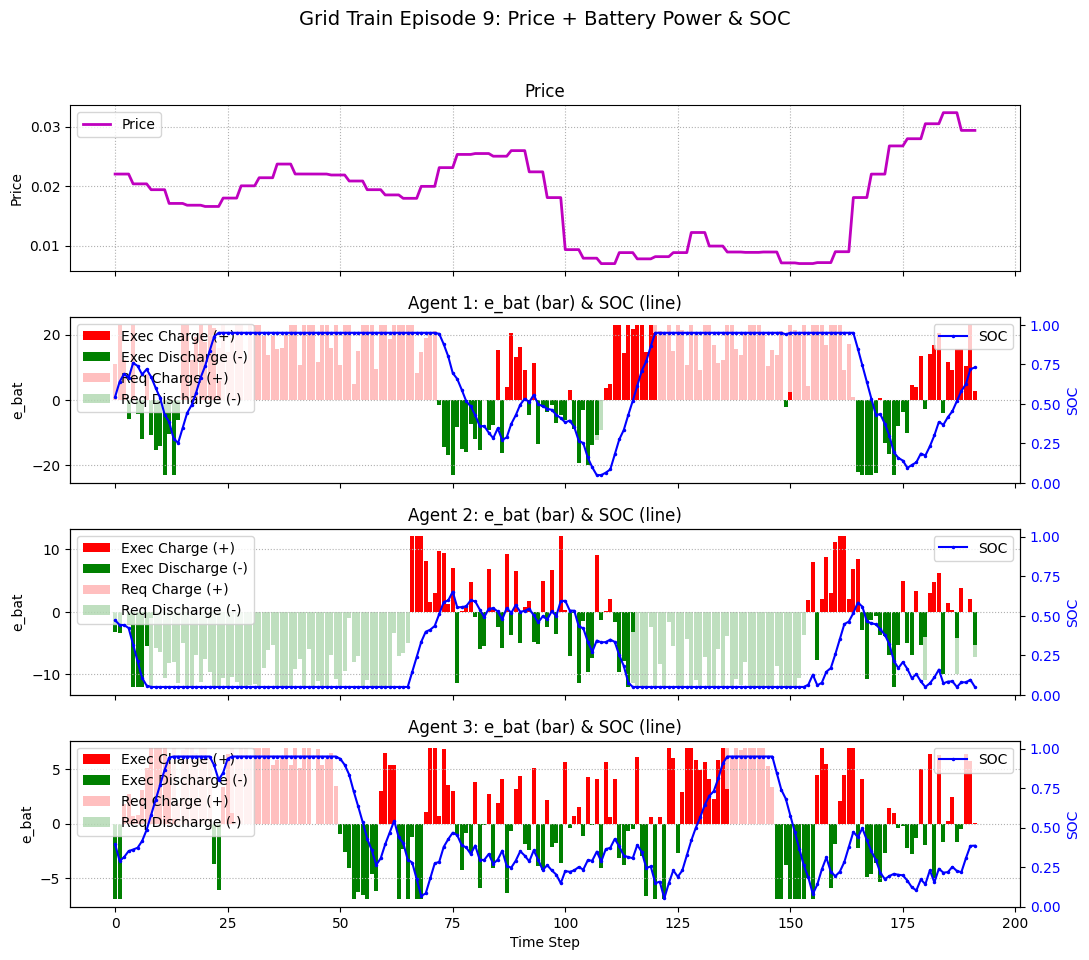

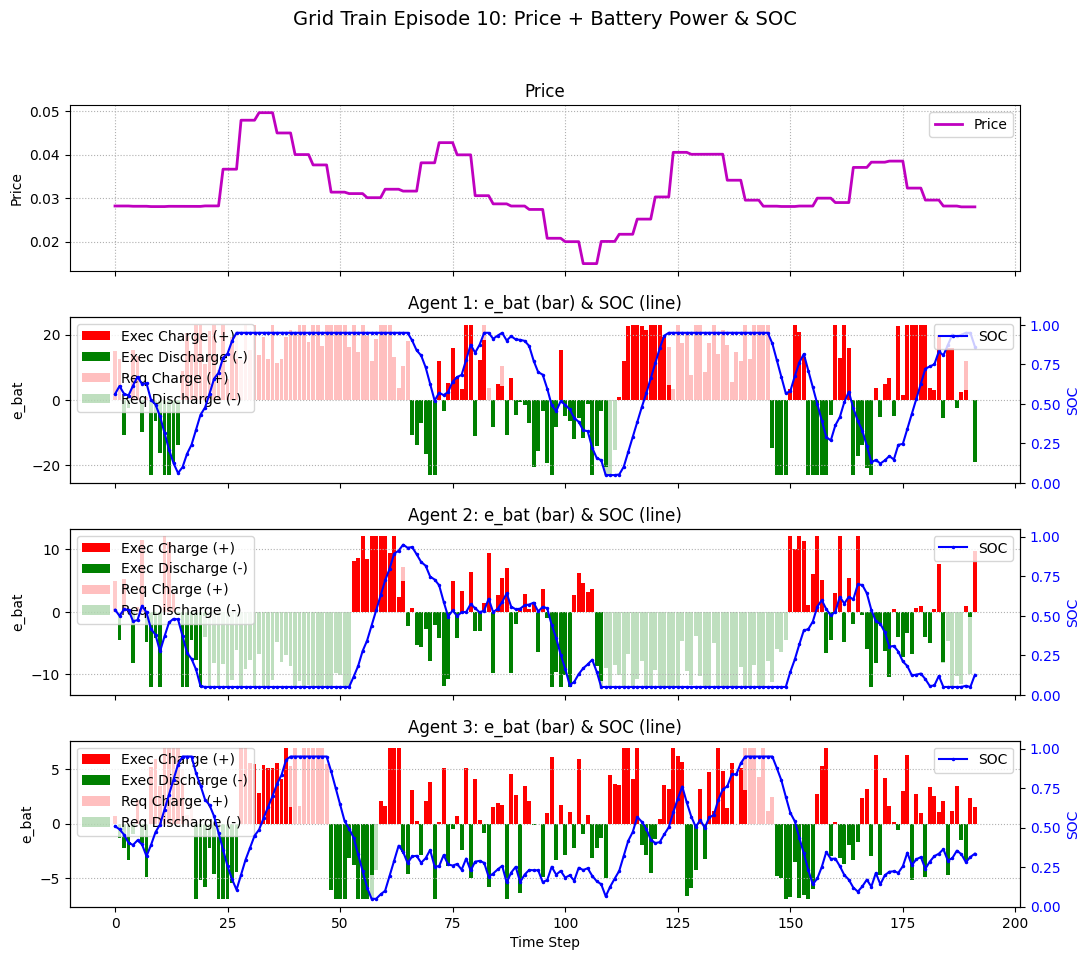

In [8]:
# 绘制最近 k 个训练 episode 的电价-动作-SoC 轨迹图
plot_last_k_episodes_price_action_soc(
    history=runner.history,
    k=n_recent_to_plot,
    n_agents=cfg.env.num_agents,
    title_prefix="Grid Train",
)

## Grid-Specific Evaluation

使用**自定义评估循环**，同时运行两个 recorder：

- `episode_recorder`（标准）— 记录 SoC、电池功率、奖励分量
- `grid_recorder`（新增）— 记录节点电压、线路负载、违规统计

内置 `evaluate_runner` 只运行前者，无法输出电压图，因此这里手动实现循环。

In [9]:
# 获取评估环境和控制器（无探索噪声）
eval_env     = runner.env_evaluate
controller   = MADRLController(runner.agent_n, noise_std=0.0)
reward_metas = eval_env.reward_fn.component_meta  # 奖励分量元信息

all_histories      = []  # 存放所有 episode 的标准记录
all_grid_histories = []  # 存放所有 episode 的电网记录

for ep_i in range(n_eval_episodes):
    obs_n = eval_env.reset()  # 重置环境，获取初始观测
    controller.reset()        # 重置控制器内部状态

    # 初始化标准 episode 记录（SoC、功率、奖励分量等）
    history      = init_episode_record(
        n_agents=eval_env.n,
        init_soc=float(eval_env.init_soc),
        reward_metas=reward_metas,
    )
    # 初始化电网记录（电压、线路负载、潮流收敛状态等）
    grid_history = init_grid_record(n_agents=eval_env.n)

    done = False
    while not done:
        action_n = controller.act(obs_n, deterministic=True)  # 确定性策略输出动作
        obs_n, r_n, done_n, info = eval_env.step(action_n)    # 环境执行一步

        # 计算当前步所有 agent 的总奖励
        step_total = float(np.sum(np.asarray(r_n, dtype=np.float32)))
        # 追加标准记录（SoC、电池功率、各奖励分量等）
        append_step_record(history, info, step_total=step_total, reward_metas=reward_metas)
        # 追加电网记录（节点电压、线路负载率、违规信息等）
        append_grid_step_record(grid_history, info)

        done = bool(info.get("episode_done", False))  # 检查 episode 是否结束

    all_histories.append(history)
    all_grid_histories.append(grid_history)

    # 打印当前 episode 的统计摘要
    n_steps = len(grid_history["pf_converged"])
    n_conv  = sum(grid_history["pf_converged"])       # 潮流计算收敛的步数
    n_vviol = sum(grid_history["n_v_violations"])     # 电压违规的步数
    n_lviol = sum(grid_history["n_l_violations"])     # 线路过载违规的步数
    print(f"Ep {ep_i+1:2d}: 步数={n_steps:3d}  潮流收敛={n_conv}/{n_steps}  "
          f"电压违规={n_vviol:3d} 步  线路违规={n_lviol:3d} 步")

# 汇总所有评估 episode 的违规统计
total_v = sum(sum(gh["n_v_violations"]) for gh in all_grid_histories)
total_l = sum(sum(gh["n_l_violations"]) for gh in all_grid_histories)
print(f"\n汇总 — 电压违规总步数: {total_v},  线路违规总步数: {total_l}")

Ep  1: 步数=192  潮流收敛=0/192  电压违规=  0 步  线路违规=  0 步
Ep  2: 步数=192  潮流收敛=0/192  电压违规=  0 步  线路违规=  0 步
Ep  3: 步数=192  潮流收敛=0/192  电压违规=  0 步  线路违规=  0 步

汇总 — 电压违规总步数: 0,  线路违规总步数: 0


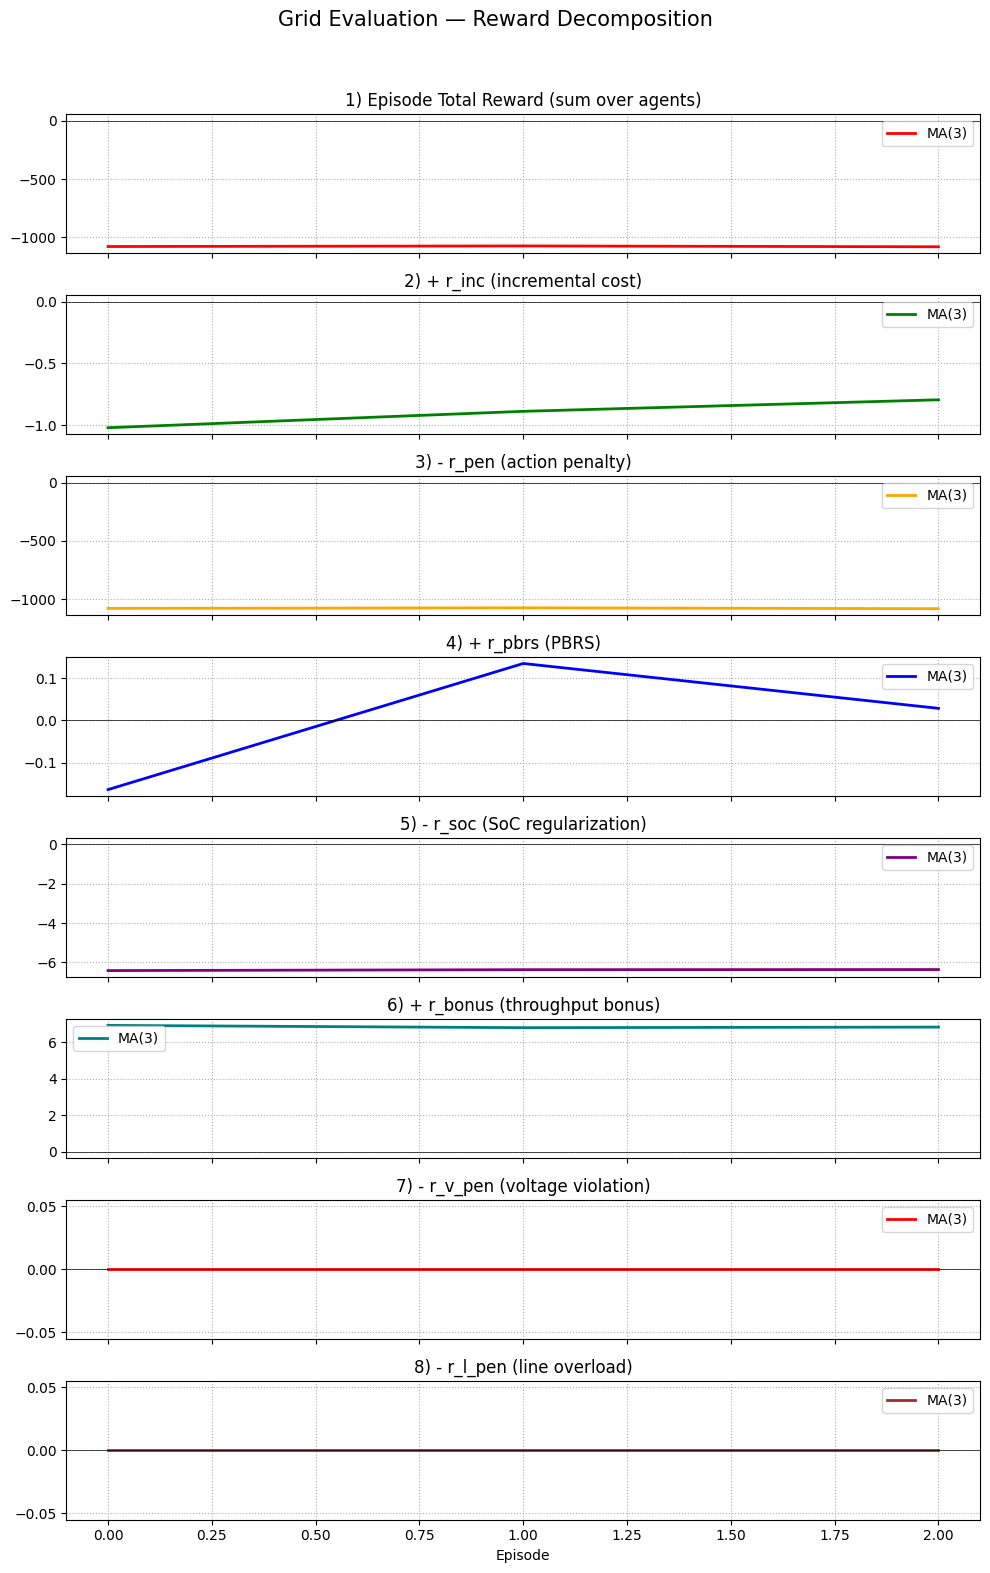

In [10]:
# 计算每个评估 episode 的总奖励
eval_episode_rewards = [sum(h["r_total_sum"]) for h in all_histories]

# 绘制评估阶段的奖励分解图
plot_reward_decomposition(
    history=all_histories,
    episode_rewards=eval_episode_rewards,
    reward_fn=plot_reward_fn,
    title="Grid Evaluation — Reward Decomposition",
    window=max(1, len(all_histories)),  # 窗口大小等于 episode 总数
)

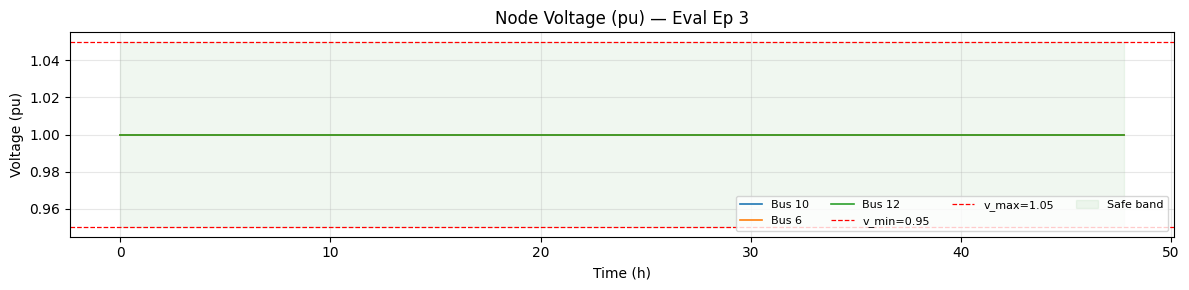

In [11]:
# 绘制最后一个评估 episode 的节点电压时序图（含上下限标注）
plot_node_voltages(
    grid_history=all_grid_histories[-1],
    v_min=cfg.grid.v_min_pu,   # 电压下限（标幺值）
    v_max=cfg.grid.v_max_pu,   # 电压上限（标幺值）
    title=f"Node Voltage (pu) — Eval Ep {n_eval_episodes}",
    agent_labels=[f"Bus {bid}" for bid in cfg.grid.agent_bus_ids],
)

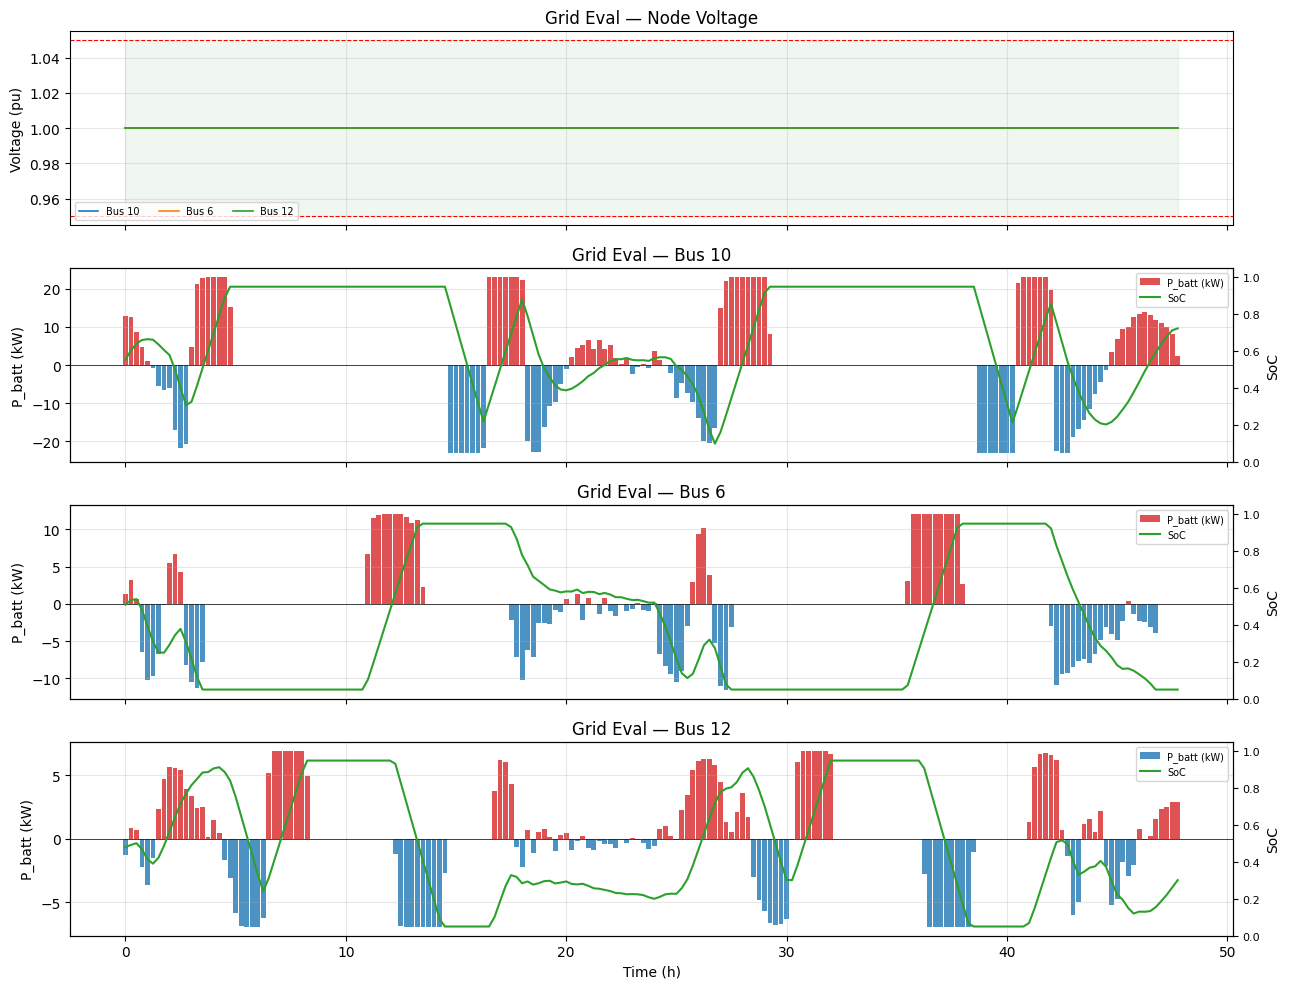

In [12]:
# 绘制复合图：顶行为节点电压，每个 agent 对应一行显示电池功率柱状图和 SoC 曲线
plot_battery_and_grid(
    history=all_histories[-1],
    grid_history=all_grid_histories[-1],
    n_agents=cfg.env.num_agents,
    v_min=cfg.grid.v_min_pu,   # 电压下限
    v_max=cfg.grid.v_max_pu,   # 电压上限
    agent_labels=[f"Bus {bid}" for bid in cfg.grid.agent_bus_ids],
    title_prefix="Grid Eval — ",
)

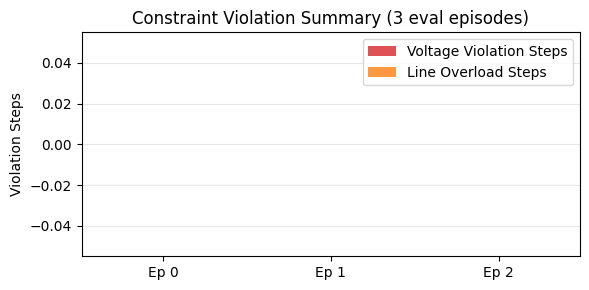

In [13]:
# 绘制所有评估 episode 的电压/线路约束违反统计柱状图
plot_grid_constraint_summary(
    grid_histories=all_grid_histories,
    title=f"Constraint Violation Summary ({n_eval_episodes} eval episodes)",
)

In [14]:
# 设置模型保存目录
save_dir = get_madrl_checkpoint_root(project_root) / "MADDPG_Grid"
save_dir.mkdir(parents=True, exist_ok=True)  # 若目录不存在则创建
# 保存训练好的模型参数
runner.save_model(str(save_dir), episode=episodes_completed)
# 关闭运行器，释放环境资源
runner.close()
print(f"模型已保存到: {save_dir}")

模型已保存到: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MADDPG_Grid
